In [8]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


In [10]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

In [104]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag2.csv')

    # Preprocessing
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime'])
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf['FirstGCS'] != 15)# & (myPredictorsDf.nurse_min_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
    myXValue = myXValue
    myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [105]:
[x for x in myPredictorsDf.columns if 'first' in x]

['diagnosis_first degree', 'nurse_first_IAP', 'lab_first_Vancomycin - peak']

In [106]:
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'DeathAtDischarge', 
                                                                         aTreatmentColumn = 'treatment_hypothermia', aDropColumns=['Hypothermia', 'both_hypothermia'], aSkipTemp = True) 

/tmp/ipykernel_235/3044954263.py:6: DtypeWarning: Columns (2060,2071,2080,2083,2084,2085,2096,2100,2261,2263) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag2.csv')


In [107]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    return [('preprocessor', myPreprocessor), ('imputer', KNNImputer(n_neighbors=10))]

In [108]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [109]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(4000, activation='relu'), #6000
    layers.Dropout(0.5),#0.2
    layers.Dense(2000, activation='relu'),#2000
    layers.Dropout(0.5),#0.1
    layers.Dense(500, activation='relu'), 
    layers.Dense(200, activation='relu'), 
    layers.Dense(50, activation='relu'), 
    layers.Dense(16, activation='relu'), 
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


In [110]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=30, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5032 - loss: 2.4062 - roc_auc: 0.4962 - val_accuracy: 0.5233 - val_loss: 0.7238 - val_roc_auc: 0.7613
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6093 - loss: 0.6555 - roc_auc: 0.6577 - val_accuracy: 0.6916 - val_loss: 0.5855 - val_roc_auc: 0.7752
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6944 - loss: 0.5886 - roc_auc: 0.7540 - val_accuracy: 0.7112 - val_loss: 0.5612 - val_roc_auc: 0.7857
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7095 - loss: 0.5576 - roc_auc: 0.7830 - val_accuracy: 0.6982 - val_loss: 0.5620 - val_roc_auc: 0.7936
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6980 - loss: 0.5679 - roc_auc: 0.7734 - val_accuracy: 0.7188 - val_loss: 0.5566 - val_roc_auc: 0.7952
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7244 - loss: 0.5454 - roc_auc: 0.7967 - val_accuracy: 0.6743 - val_loss: 0.6242 - val_roc_auc: 0.796

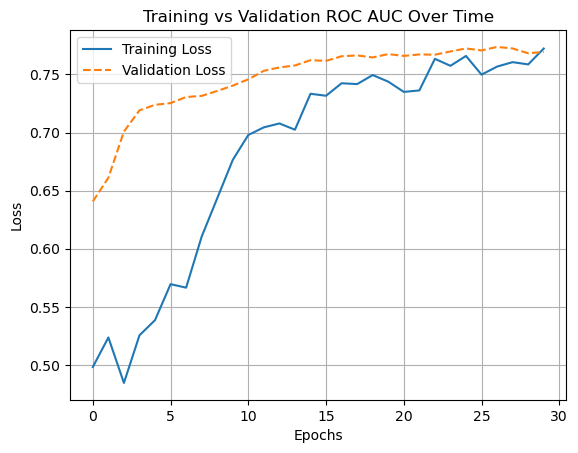

In [77]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [78]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
ROC AUC Score: 0.7695


In [79]:
y_pred_probs.T[0, :]

array([0.84896207, 0.777444  , 0.5945134 , 0.67997634, 0.56610155,
       0.55290836, 0.45225132, 0.7673129 , 0.7527637 , 0.33974695,
       0.34345806, 0.8859349 , 0.9374289 , 0.6233569 , 0.33924007,
       0.39595008, 0.53247297, 0.7617712 , 0.85198355, 0.8452434 ,
       0.8085375 , 0.70392853, 0.89128274, 0.46399885, 0.4717939 ,
       0.26990557, 0.38209486, 0.9167702 , 0.9147049 , 0.9491556 ,
       0.45593897, 0.39345804, 0.9201052 , 0.6874214 , 0.3738942 ,
       0.7068558 , 0.58316344, 0.48190877, 0.46521765, 0.8034461 ,
       0.49828428, 0.58027494, 0.49764276, 0.62510026, 0.7838242 ,
       0.9348261 , 0.55118364, 0.7392547 , 0.82732797, 0.6538673 ,
       0.7946555 , 0.4023672 , 0.6256596 , 0.852084  , 0.746089  ,
       0.54071194, 0.49725232, 0.83459884, 0.7844362 , 0.5190201 ,
       0.6897625 , 0.31997964, 0.72804475, 0.40560013, 0.6981171 ,
       0.4450769 , 0.9485414 , 0.83485574, 0.59692705, 0.73215115,
       0.6750407 , 0.7645294 , 0.60019267, 0.56872654, 0.75670

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Optimization terminated successfully.
         Current function value: 0.677188
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.677171
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 0.05911921020515365
p-value: 0.80789351936054
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1726
Model:                          Logit   Df Residuals:                     1723
Method:                           MLE   Df Model:                            2
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                0.002327
Time:                        15:14:01   Log-Likelihood:                -1168.8
converged:                       True   LL-Null:                       -1171.6
Covariance Type:      

0.80789351936054

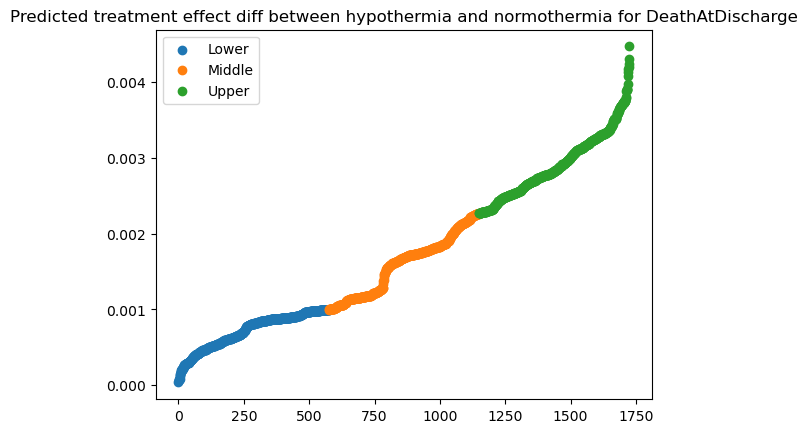

In [81]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Optimization terminated successfully.
         Current function value: 0.676234
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.676226
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 0.012424910910908693
p-value: 0.911245965728361
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  740
Model:                          Logit   Df Residuals:                      737
Method:                           MLE   Df Model:                            2
Date:                Sun, 02 Mar 2025   Pseudo R-squ.:                0.003457
Time:                        15:14:26   Log-Likelihood:                -500.41
converged:                       True   LL-Null:                       -502.15
Covariance Type:     

0.911245965728361

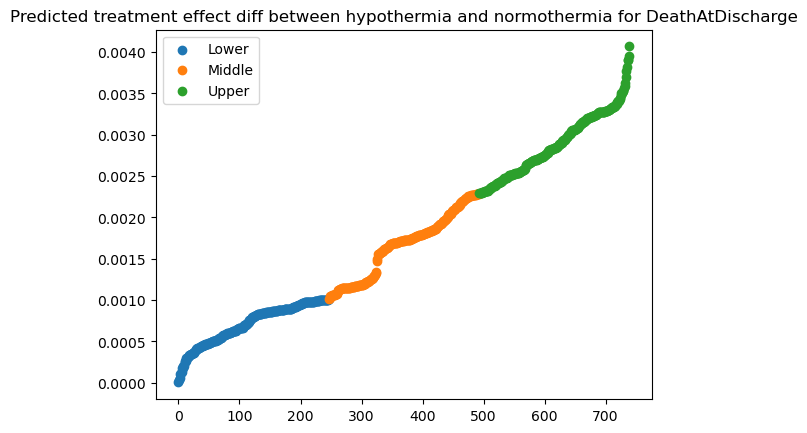

In [82]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

['nurse_last_Motor', 'nurse_max_Motor', 'nurse_min_Motor', 'nurse_mean_Motor']

In [46]:
myPredictorsDf[myPredictorsDf.nurse_max_Motor == 6]

,patientunitstayid,gender,age,apacheadmissiondx,admissionheight,hospitaladmittime24,hospitaladmitsource,admissionweight,treatment_5-10 cm H2O,treatment_50-60%,...,lab_max_Site,lab_min_Site,lab_mean_Site,lab_max_cd 4,lab_min_cd 4,lab_mean_cd 4,hospitaldischargestatus,DeathAtDischarge,LastGCS15,LastMGCSPositive
116,244718,0,57,Seizures (primary-no structural brain disease),154.90,02:59:00,NaN,54.7,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Alive,0,0,1.0
117,246179,1,48,"Fracture-pathological, non-union, non-traumati...",177.80,10:32:00,Operating Room,99.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Alive,0,0,1.0
132,260200,1,27,Cardiac arrest (with or without respiratory ar...,175.26,21:16:00,Emergency Department,67.6,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Alive,0,0,1.0
138,267666,0,77,Cardiac arrest (with or without respiratory ar...,172.70,23:07:00,Emergency Department,159.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Alive,0,0,1.0
146,285992,1,84,Cardiac arrest (with or without respiratory ar...,180.30,16:33:00,NaN,73.2,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Alive,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,3341527,1,76,Cardiac arrest (with or without respiratory ar...,188.00,13:43:00,Floor,113.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Expired,1,0,0.0
3330,3341869,0,87,Cardiac arrest (with or without respiratory ar...,152.40,02:54:00,Step-Down Unit (SDU),41.6,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Expired,1,0,0.0
3351,3344645,1,79,Cardiac arrest (with or without respiratory ar...,180.30,23:35:00,Floor,98.8,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Expired,1,0,0.0
3357,3345171,0,76,"CHF, congestive heart failure",157.50,12:55:00,Emergency Department,100.4,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Expired,1,0,0.0
